# Analisis dan Pemodelan Prediksi Kawasan Kumuh (Slum) Menggunakan Semua Fitur
### Pendekatan Robust: Spatially-Independent & Leakage-Free

Notebook ini memperbaiki versi sebelumnya dengan menangani masalah kritis berikut:
1. **Menggunakan Seluruh Fitur Spektral & Radar** (bukan hanya bangunan), tetapi mengeksklusi `city` dari fitur untuk menghindari shortcut prevalensi.
2. **Leave-One-City-Out (LOCO) Cross-Validation** untuk mencegah kebocoran autokorelasi spasial.
3. **Metrik Utama PR-AUC & Recall** untuk menangani ketidakseimbangan kelas (~14% slum).
4. **Tuning Threshold Klasifikasi** berdasarkan probabilitas Out-of-Fold (OOF) untuk memaksimalkan F1-Score.
5. **Menghapus Standarisasi Fitur** yang tidak diperlukan oleh algoritma berbasis pohon (XGBoost).

## 1. Import Library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import LeaveOneGroupOut, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, 
    f1_score, average_precision_score, roc_auc_score, roc_curve
)
import shap

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Data Preparation

In [6]:
# Load dataset
df = pd.read_csv('../data/processed/features_buildings.csv')

# Memisahkan target (y) dan variabel grouping spasial (groups)
y = df['slum']
groups = df['city']

# Menggunakan SEMUA fitur spektral, radar, dan bangunan
# Mengeluarkan 'slum' (target), 'unit_id' (identifier), dan 'city' (variabel grup, BUKAN fitur)
X = df.drop(columns=['slum', 'unit_id', 'city'])

print(f"Jumlah sampel: {X.shape[0]}")
print(f"Jumlah fitur yang digunakan: {X.shape[1]}")
print("\nDaftar kota unik untuk LOCO Validation:", groups.unique())
print(f"Prevalensi kelas Slum: {(y.sum()/len(y))*100:.2f}%")

Jumlah sampel: 828
Jumlah fitur yang digunakan: 35

Daftar kota unik untuk LOCO Validation: <StringArray>
['ambon', 'dki', 'kebumen', 'samarinda']
Length: 4, dtype: str
Prevalensi kelas Slum: 14.25%


## 3. Exploratory Data Analysis (EDA) - Korelasi & Analisis Multivariat

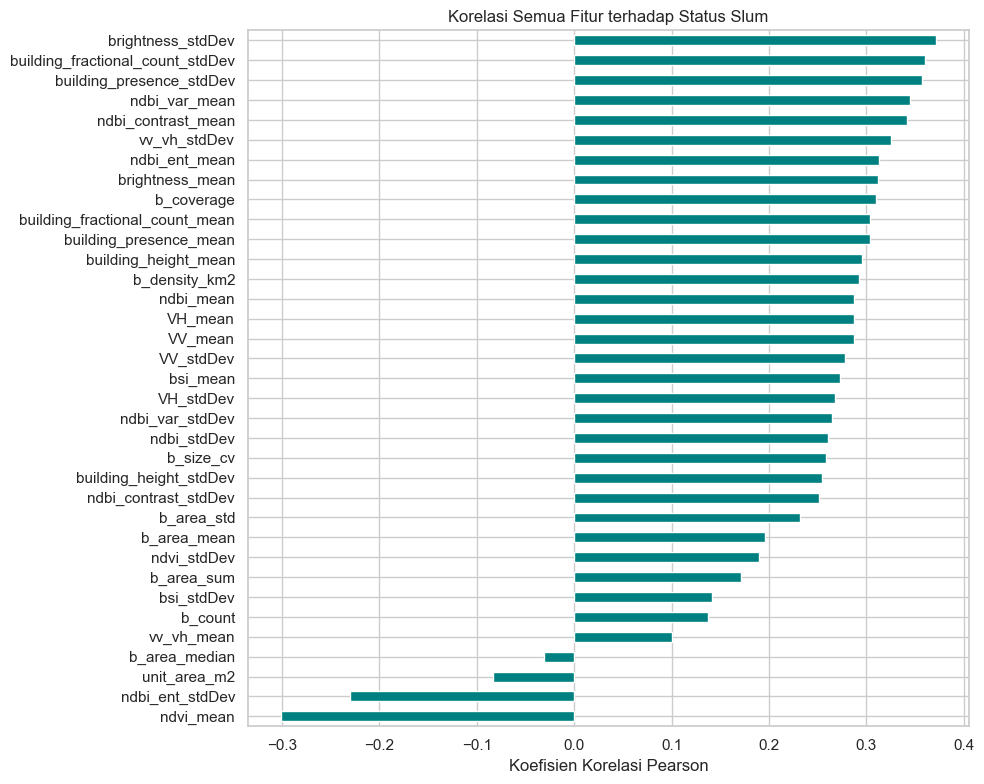

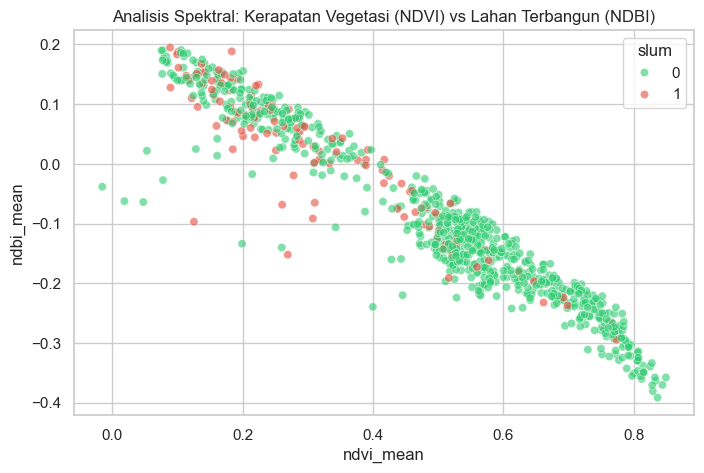

In [7]:
sns.set_theme(style="whitegrid")

# 1. Hitung korelasi semua fitur terhadap target slum untuk melihat fitur spektral/radar mana yang dominan
correlations = df.drop(columns=['unit_id', 'city']).corr()['slum'].sort_values()

plt.figure(figsize=(10, 8))
correlations.drop('slum').plot(kind='barh', color='teal')
plt.title('Korelasi Semua Fitur terhadap Status Slum')
plt.xlabel('Koefisien Korelasi Pearson')
plt.tight_layout()
plt.show()

# 2. Visualisasi sebaran dua fitur lintas indeks: NDVI vs NDBI
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='ndvi_mean', y='ndbi_mean', hue='slum', alpha=0.6, palette=['#2ecc71', '#e74c3c'])
plt.title('Analisis Spektral: Kerapatan Vegetasi (NDVI) vs Lahan Terbangun (NDBI)')
plt.show()

## 4. Leave-One-City-Out (LOCO) Validation & Hyperparameter Tuning

In [8]:
# Inisialisasi LeaveOneGroupOut
logo = LeaveOneGroupOut()

# Menghitung rasio imbalance secara global untuk baseline penyeimbang pohon
ratio_global = float(np.sum(y == 0)) / np.sum(y == 1)

# Base model XGBoost
xgb_base = XGBClassifier(
    scale_pos_weight=ratio_global,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Definisi hyperparameter grid
param_comb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

# Pencarian hyperparameter menggunakan strategi LOCO sebagai CV splitter
# Metrik optimasi diubah ke 'average_precision' (PR-AUC)
search_loco = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_comb,
    n_iter=15,
    scoring='average_precision',
    cv=logo,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Melakukan Hyperparameter Tuning dengan LOCO CV (Memprediksi Kota Baru)...")
search_loco.fit(X, y, groups=groups)

print(f"\nParameter Terbaik: {search_loco.best_params_}")
print(f"Best Lintas-Kota PR-AUC: {search_loco.best_score_:.4f}")

best_xgb = search_loco.best_estimator_

Melakukan Hyperparameter Tuning dengan LOCO CV (Memprediksi Kota Baru)...
Fitting 4 folds for each of 15 candidates, totalling 60 fits

Parameter Terbaik: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best Lintas-Kota PR-AUC: 0.4531


## 5. Ekstraksi Prediksi Out-of-Fold (OOF) & Tuning Threshold Klasifikasi

Threshold Optimal Berdasarkan F1-Score Terbesar: 0.09
F1-Score Maksimum Out-of-Fold: 0.4283


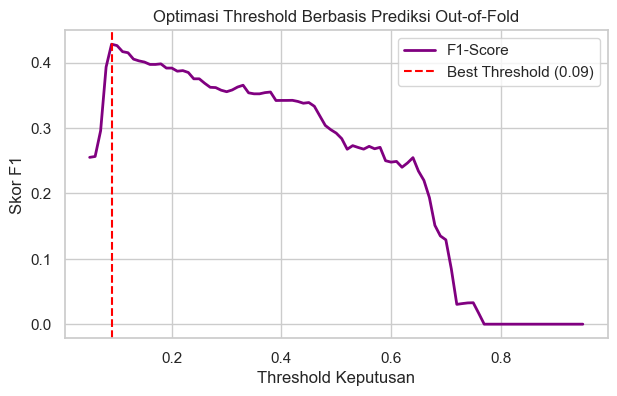

In [9]:
# Membuat array kosong untuk menampung probabilitas out-of-fold jujur tanpa leakage
oof_pred_proba = np.zeros(len(y))

# Lakukan iterasi LOCO secara manual menggunakan parameter terbaik untuk mendapatkan probabilitas murni
for train_idx, test_idx in logo.split(X, y, groups=groups):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_ts = X.iloc[test_idx]
    
    # Fit model pada N-1 kota
    model_fold = XGBClassifier(**search_loco.best_params_, random_state=42, eval_metric='logloss')
    model_fold.fit(X_tr, y_tr)
    
    # Prediksi probabilitas pada kota yang ditinggalkan
    oof_pred_proba[test_idx] = model_fold.predict_proba(X_ts)[:, 1]

# Cari threshold terbaik yang mengoptimalkan F1-Score
thresholds = np.linspace(0.05, 0.95, 91)
f1_scores = [f1_score(y, (oof_pred_proba >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Threshold Optimal Berdasarkan F1-Score Terbesar: {best_threshold:.2f}")
print(f"F1-Score Maksimum Out-of-Fold: {f1_scores[best_idx]:.4f}")

# Plot Grafik Optimasi Threshold
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores, label='F1-Score', color='purple', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Threshold Keputusan')
plt.ylabel('Skor F1')
plt.title('Optimasi Threshold Berbasis Prediksi Out-of-Fold')
plt.legend()
plt.show()

## 6. Evaluasi Akhir Menggunakan Metrik Robust untuk Data Imbalance

=== LAPORAN KLASIFIKASI (Jujur Lintas Kota - LOCO) ===
              precision    recall  f1-score   support

           0       0.97      0.63      0.77       710
           1       0.28      0.87      0.43       118

    accuracy                           0.67       828
   macro avg       0.63      0.75      0.60       828
weighted avg       0.87      0.67      0.72       828

Headline PR-AUC (Precision-Recall AUC): 0.2590
ROC-AUC (Sebagai Perbandingan): 0.7394


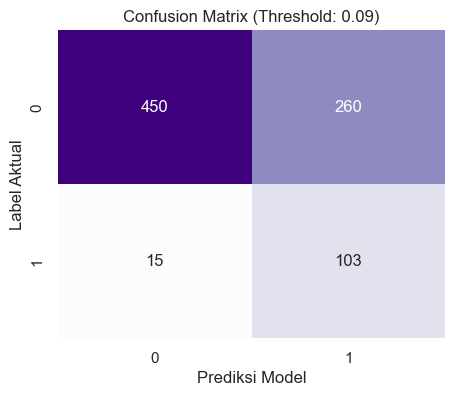

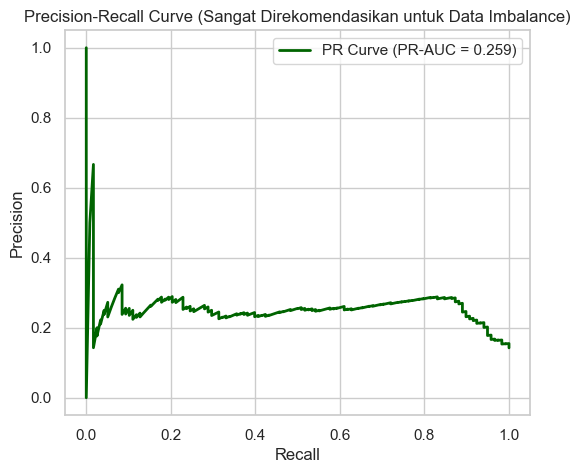

In [10]:
# Konversi probabilitas OOF menjadi kelas biner menggunakan threshold optimal yang baru
y_pred_adjusted = (oof_pred_proba >= best_threshold).astype(int)

print("=== LAPORAN KLASIFIKASI (Jujur Lintas Kota - LOCO) ===")
print(classification_report(y, y_pred_adjusted))

# 1. Hitung Headline Metrics
pr_auc = average_precision_score(y, oof_pred_proba)
roc_auc = roc_auc_score(y, oof_pred_proba)
print(f"Headline PR-AUC (Precision-Recall AUC): {pr_auc:.4f}")
print(f"ROC-AUC (Sebagai Perbandingan): {roc_auc:.4f}")

# 2. Plot Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y, y_pred_adjusted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title(f'Confusion Matrix (Threshold: {best_threshold:.2f})')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Aktual')
plt.show()

# 3. Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y, oof_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PR Curve (PR-AUC = {pr_auc:.3f})', color='darkgreen', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Sangat Direkomendasikan untuk Data Imbalance)')
plt.legend()
plt.show()

## 7. Murni Analisis Interpretasi Fitur Menggunakan SHAP

--- SHAP Summary Plot (Kontribusi Semua Fitur Tanpa Kebocoran Shortcut Kota) ---


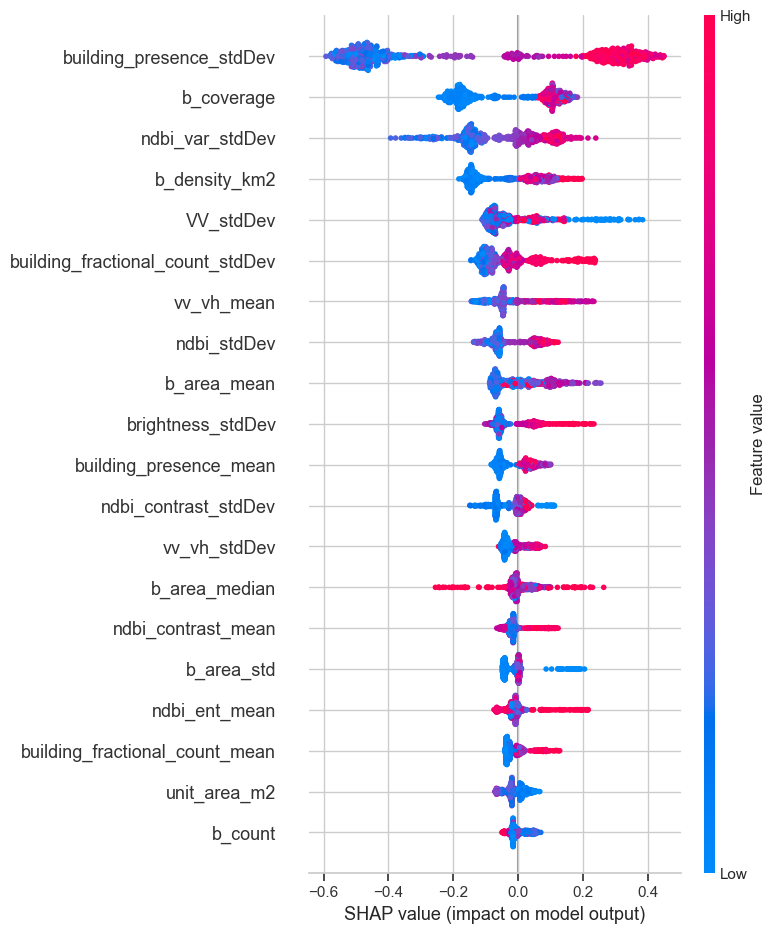

In [11]:
# Melatih model final pada keseluruhan dataset untuk analisis kontribusi global fitur secara murni
final_model = XGBClassifier(**search_loco.best_params_, random_state=42, eval_metric='logloss')
final_model.fit(X, y)

# Inisialisasi SHAP TreeExplainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

print("--- SHAP Summary Plot (Kontribusi Semua Fitur Tanpa Kebocoran Shortcut Kota) ---")
plt.figure()
shap.summary_plot(shap_values, X)

## 8. Robust Inference Pipeline

In [12]:
def pipeline_prediksi_wilayah_baru(df_baru, model, threshold):
    """
    Fungsi inferensi untuk memprediksi data dari kota yang sepenuhnya baru.
    Menghilangkan kolom non-fitur secara otomatis untuk mencocokkan dimensi input.
    """
    # Proteksi kolom non-fitur jika terbawa saat pemanggilan data baru
    kolom_diabaikan = ['slum', 'unit_id', 'city']
    fitur_bersih = df_baru.drop(columns=[c for c in kolom_diabaikan if c in df_baru.columns])
    
    # Prediksi probabilitas
    probabilitas = model.predict_proba(fitur_bersih)[:, 1]
    kelas_prediksi = (probabilitas >= threshold).astype(int)
    
    hasil = df_baru.copy()
    hasil['Probabilitas_Slum'] = probabilitas
    hasil['Prediksi_Status_Slum'] = kelas_prediksi
    return hasil

# Simulasi inferensi menggunakan 5 baris data
simulasi_data_baru = df.sample(5, random_state=10).copy()
hasil_inferensi = pipeline_prediksi_wilayah_baru(simulasi_data_baru, final_model, best_threshold)

hasil_inferensi[['unit_id', 'city', 'Probabilitas_Slum', 'Prediksi_Status_Slum']]

,unit_id,city,Probabilitas_Slum,Prediksi_Status_Slum
339,kebumen_0028,kebumen,0.032468,0
68,dki_0018,dki,0.173590,1
264,dki_0214,dki,0.263190,1
278,dki_0228,dki,0.175165,1
529,kebumen_0218,kebumen,0.390226,1
